# 🗺️ 第 61 课 · AI 编译器全景:为什么需要、怎么工作

> TVM / MLIR / XLA / Inductor 殊途同归:前端 → IR → 优化 → 后端,把『看得懂』降到『跑得快』

**章节**: 第 10 章 · AI 编译器原理

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解为什么需要 AI 编译器:算子 × 形状 × 精度 × 硬件的组合爆炸,手写内核不可持续
- 掌握编译流水线的四段式:前端 → IR → 优化 → 后端,并知道每一段在干什么
- 对比传统编译器(GCC/LLVM)与 AI 编译器(以张量、kernel、调度为核心)的差异
- 认识主流 AI 编译器生态:TVM、MLIR、XLA、torch.compile/Inductor、Triton 的定位
- 用 matplotlib + seaborn 画出全景结构图、组合爆炸图与生态矩阵
- 跑通配套 App:交互浏览不同框架的编译流水线

## 📑 本课目录

1. **直觉:一锅炖与组合爆炸** — 手写内核为什么不可持续:组合空间爆炸
2. **传统 vs AI 编译器** — 输入、IR、优化目标、输出的本质差别
3. **编译流水线四段式** — 前端 → IR → 优化 → 后端,全景结构图
4. **主流生态一图看懂** — TVM / MLIR / XLA / Inductor / Triton 的层次矩阵
5. **真跑一遍:前端与图** — 用 torch.fx 亲眼看『模型 → 图』这一步
6. **配套 App** — app_61_compiler_overview.py:交互浏览流水线

## 🔗 参考资料

- [TVM 论文(2018)](https://arxiv.org/abs/1802.04799)
- [MLIR 论文(2020)](https://arxiv.org/abs/2002.11054)
- [XLA 文档](https://www.tensorflow.org/xla)
- [PyTorch torch.compiler 文档](https://pytorch.org/docs/stable/torch.compiler.html)
- [Triton 编译器](https://openai.com/index/triton/)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头(后续所有图都走 matplotlib + seaborn)。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 Anaconda/torch 的 OMP 库冲突(Windows)
import time, json, io, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


## 1️⃣ 直觉:一锅炖与组合爆炸 🍲

深度学习框架给你一堆**算子**(matmul、relu、softmax……),每个算子你都得在目标硬件上实现一遍,
要么调用厂商库(cuBLAS/cuDNN),要么手写 CUDA kernel。问题是:这个组合空间会**爆炸**:

- 算子种类:几百种;
- 每种算子的形状:几十种常见 shape;
- 精度:fp32 / fp16 / bf16 / int8 / tf32……;
- 硬件架构:不同代际的 GPU、CPU、NPU、TPU。

算一下:几百 × 几十 × 若干精度 × 若干硬件 —— 手写内核的数量级是**千到百万**。这就像每家餐厅
都要自己种菜、自己设计灶台、自己写菜谱 —— 根本不可持续。**AI 编译器**的答案:把"写菜谱"这件事
自动化 —— 你用高层语言描述"想吃什么",编译器负责"怎么用现有的灶具做出来、并尽量做快"。

📊 组合爆炸图:每叠加一个维度,所需手写 kernel 的数量级翻几番 —— 这就是 AI 编译器存在的根本理由。

组合空间 ≈ 300 × 40 × 4 × 5 = 240,000 个『算子×形状×精度×硬件』组合
而一位工程师一个月手写并调优的 kernel,最多几十个 —— 差的不是一点半点。


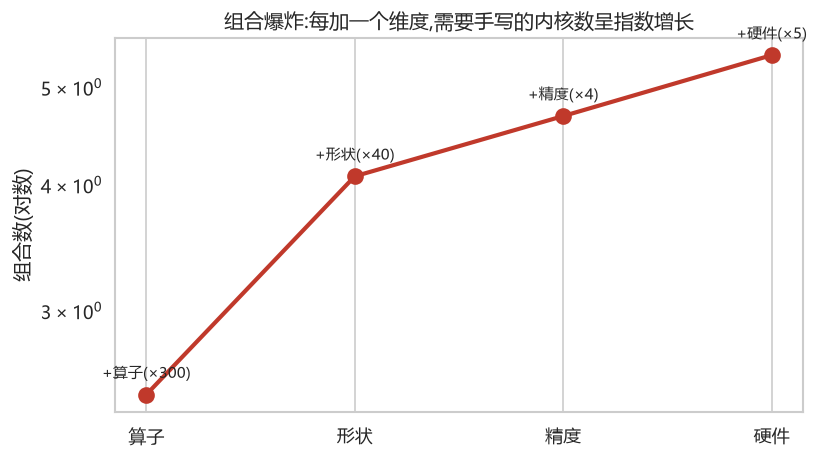

In [2]:
ops = 300            # 算子种类
shapes = 40          # 常见形状
precisions = 4       # fp32/fp16/bf16/int8
hardwares = 5        # 不同代际/厂商硬件

import numpy as np
combo = ops * shapes * precisions * hardwares
print(f"组合空间 ≈ {ops} × {shapes} × {precisions} × {hardwares} = {combo:,} 个『算子×形状×精度×硬件』组合")
print("而一位工程师一个月手写并调优的 kernel,最多几十个 —— 差的不是一点半点。")

# 可视化:组合数随维度线性叠加的直观感受
dims = ["算子", "形状", "精度", "硬件"]
counts = [ops, shapes, precisions, hardwares]
acc = 1
cum = []
for c in counts:
    acc *= c
    cum.append(acc)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(dims) + 1), np.log10(cum), "o-", color="#c0392b", lw=2.5, ms=9)
for i, (d, c, v) in enumerate(zip(dims, counts, np.log10(cum)), 1):
    ax.annotate(f"+{d}(×{c})", (i, v), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
ax.set_yscale("log")
ax.set_xticks(range(1, len(dims) + 1)); ax.set_xticklabels(dims)
ax.set_ylabel("组合数(对数)")
ax.set_title("组合爆炸:每加一个维度,需要手写的内核数呈指数增长")
plt.tight_layout()

## 2️⃣ 传统编译器 vs AI 编译器 ⚖️

两者共享"前端 → 优化 → 后端"的骨架,但**输入与目标**完全不同:

| 维度 | 传统编译器(GCC/LLVM) | AI 编译器(TVM/Inductor) |
|---|---|---|
| 输入 | 过程式语言(C/C++) | 计算图 / 张量表达式 / 神经网络 |
| 基本单元 | 标量、指令、控制流 | **张量、算子、kernel** |
| 优化重点 | 指令选择、寄存器分配、循环优化 | **算子融合、layout、tiling、调度** |
| 调度 | 静态为主 | 大量**自动调度/自动调优**(搜索 tile、warp、并行度) |
| 输出 | 机器码 | 高性能 kernel(经 Triton/CUDA/LLVM) |
| 形状依赖 | 编译时定死 | 常依赖**运行时形状**(JIT) |

一句话:**传统编译器优化"一个标量循环",AI 编译器优化"一堆张量算子"。** 前者把 C 语言翻译成指令,
后者把"神经网络"翻译成一组能高效跑在 GPU 上的 kernel,并且常常在运行时按真实形状现场编译(JIT)。

📊 雷达式对比用分组柱状图代替:AI 编译器把火力集中在张量层优化,传统编译器集中在指令层。

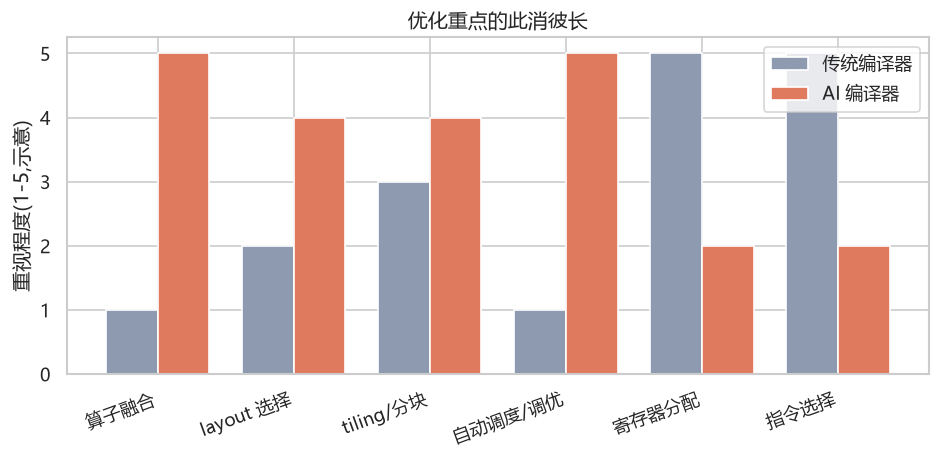

In [3]:
# 对比表可视化:优化重点的分量对比
labels = ["算子融合", "layout 选择", "tiling/分块", "自动调度/调优", "寄存器分配", "指令选择"]
traditional = [1, 2, 3, 1, 5, 5]      # 传统编译器更重视底层
ai = [5, 4, 4, 5, 2, 2]               # AI 编译器更重视张量层

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w / 2, traditional, w, label="传统编译器", color="#8e9aaf")
ax.bar(x + w / 2, ai, w, label="AI 编译器", color="#e07a5f")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("重视程度(1-5,示意)")
ax.set_title("优化重点的此消彼长")
ax.legend(); plt.tight_layout()

## 3️⃣ 编译流水线:前端 → IR → 优化 → 后端 🏭

无论哪个框架,主干都是同一条流水线:

1. **前端(Frontend)**:把用户写的模型/算子表达式,追踪(trace)成一张**计算图(IR)**。对应到 torch 就是
   `TorchDynamo` 把 Python 代码捕获成 `FX Graph`;对应到 TVM 就是 Relay/TE。
2. **IR(中间表示)**:一个"既能看懂、又能优化"的抽象。**关键思想是多级 IR** —— 高层 IR 贴近语义好做融合,
   低层 IR 贴近硬件好做代码生成,中间用 pass 逐级降低(MLIR 的 dialect、TVM 的 TensorIR 都在做这件事)。
3. **优化(Optimize)**:在 IR 上跑一串 **pass**:算子融合、常量折叠、死代码消除、layout 转换、tiling、向量化……
   这一层决定"算得快不快"。
4. **后端(Backend)**:把优化后的 IR 翻译成目标硬件的可执行代码 —— GPU 上就是 Triton/CUDA kernel。

下面用 matplotlib 画这张全景结构图,并标注每一段的输入与产出。

🎨 全景结构图:五段式流水线,箭头表示『降低/翻译』方向。这是理解全书 61-70 课的总地图。

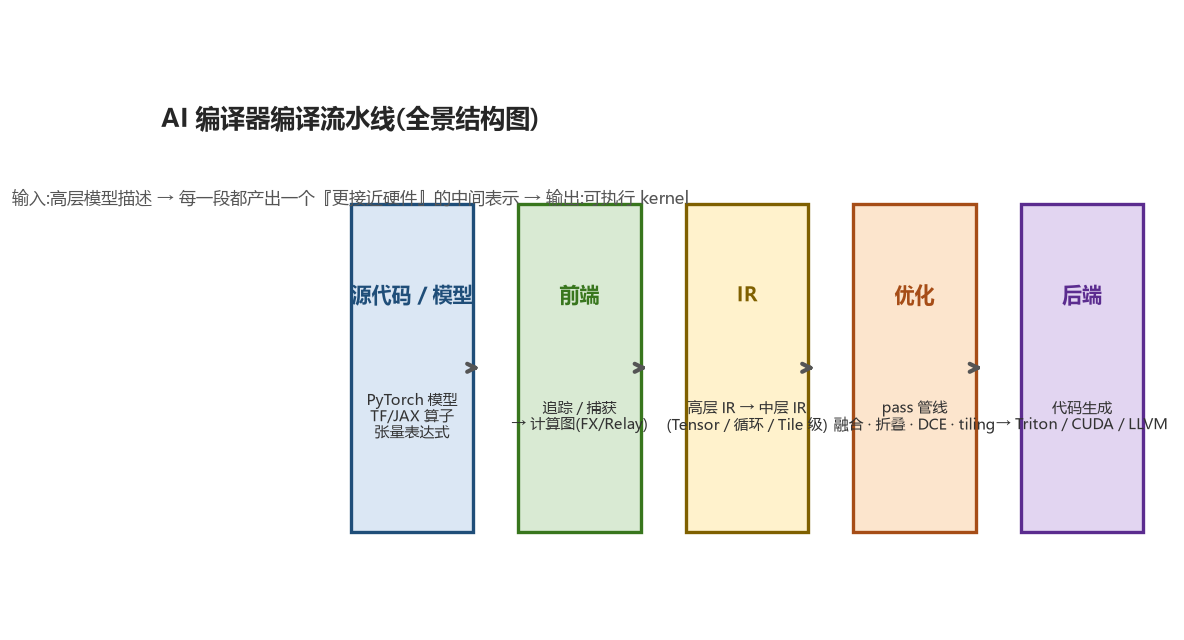

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axis("off")
stages = [
    ("源代码 / 模型", "PyTorch 模型\nTF/JAX 算子\n张量表达式", "#dbe7f4", "#1f4e79"),
    ("前端", "追踪 / 捕获\n→ 计算图(FX/Relay)", "#d9ead3", "#38761d"),
    ("IR", "高层 IR → 中层 IR\n(Tensor / 循环 / Tile 级)", "#fff2cc", "#7f6000"),
    ("优化", "pass 管线\n融合 · 折叠 · DCE · tiling", "#fce5cd", "#a64d17"),
    ("后端", "代码生成\n→ Triton / CUDA / LLVM", "#e2d5f1", "#5b2c8f"),
]
box_w, box_h = 1.5, 1.7
x = 0.5
for i, (title, sub, fill, edge) in enumerate(stages):
    ax.add_patch(plt.Rectangle((x, 0.5), box_w, box_h, facecolor=fill, edgecolor=edge, lw=2))
    ax.text(x + box_w / 2, 0.5 + box_h * 0.72, title, ha="center", va="center", fontsize=12, fontweight="bold", color=edge)
    ax.text(x + box_w / 2, 0.5 + box_h * 0.35, sub, ha="center", va="center", fontsize=9, color="#333")
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + box_w + 0.12, 1.35), xytext=(x + box_w - 0.05, 1.35),
                    arrowprops=dict(arrowstyle="->", lw=2.5, color="#555"))
    x += box_w + 0.55
ax.text(0.5, 2.6, "AI 编译器编译流水线(全景结构图)", fontsize=15, fontweight="bold", ha="center")
ax.text(0.5, 2.2, "输入:高层模型描述 → 每一段都产出一个『更接近硬件』的中间表示 → 输出:可执行 kernel",
        fontsize=10, ha="center", color="#555")
ax.set_xlim(0, x - 0.2); ax.set_ylim(0, 3.2)
plt.tight_layout()

## 4️⃣ 主流 AI 编译器生态:一张矩阵看懂 📐

把主流方案放到"抽象层次 × 产品"的矩阵里,就能看清各自的定位:

- **TVM**:最完整的开源 AI 编译器栈,前端(Rely)+ 自研 IR(TensorIR)+ 自动调度(Ansor)。
- **MLIR**:Google 的"编译器积木箱",用 dialect 描述任意抽象层次,是 TVM/XLA 的下层基建。
- **XLA**:Google 深度学习编译器,以整图融合著称(HLO)。
- **torch.compile / Inductor**:PyTorch 自带 JIT,把 eager 小算子并成大 Triton/C++ kernel。
- **Triton**:一门"CUDA 领域语言",编译器负责把 tile 式写法映射到 GPU 并行;Inductor 的后端。

下面用 seaborn 热力图画"每个编译器覆盖了哪几层",再用 pyecharts 对比各家的"编译时 vs 运行时"侧重。

📊 生态矩阵:TVM/XLA/Inductor 都是『全栈』,MLIR 是基建,而 Triton 专注『调度 + 代码生成』这一层。

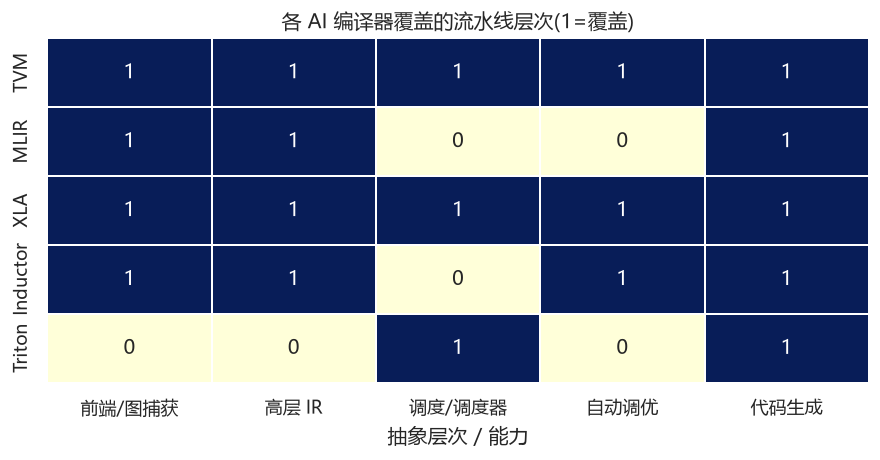

In [5]:
import seaborn as sns
framework_level = pd.DataFrame({
    "前端/图捕获": [1, 1, 1, 1, 0],
    "高层 IR":      [1, 1, 1, 1, 0],
    "调度/调度器":   [1, 0, 1, 0, 1],
    "自动调优":      [1, 0, 1, 1, 0],
    "代码生成":      [1, 1, 1, 1, 1],
}, index=["TVM", "MLIR", "XLA", "Inductor", "Triton"])

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.heatmap(framework_level, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
            linewidths=1, linecolor="white", ax=ax)
ax.set_title("各 AI 编译器覆盖的流水线层次(1=覆盖)")
ax.set_xlabel("抽象层次 / 能力")
plt.tight_layout()

📈 pyecharts 交互柱状图:横向对比各方案『重编译 / 重运行时』的侧重 —— 悬停可看数值。

In [6]:
from pyecharts.charts import Bar
from pyecharts import options as opts
names = ["TVM", "MLIR", "XLA", "Inductor", "Triton"]
compile_time = [4, 3, 3, 2, 1]   # 编译/设计成本(示意,越大越重)
runtime_flex = [5, 4, 4, 5, 5]   # 运行时/JIT 灵活度(示意)
bar = (Bar()
       .add_xaxis(names)
       .add_yaxis("编译/设计成本(重)", compile_time, color="#c0392b")
       .add_yaxis("运行时 JIT 灵活度", runtime_flex, color="#27ae60")
       .set_global_opts(title_opts=opts.TitleOpts(title="各方案的设计侧重(示意打分)"),
                        yaxis_opts=opts.AxisOpts(name="分数")))
bar.render_notebook()

## 5️⃣ 真跑一遍:亲眼看到『前端 → 图』🔬

纸上得来终觉浅。我们用 `torch.fx` 把一小段 Python 计算**追踪成计算图**,这就是编译流水线里
**前端**的产物。注意:这里只有"图",还没优化、还没生成 kernel —— 接下来的课(62 优化、66 到后端)
会逐步补全。

🔍 前端的关键产物是一张『计算图』:每个节点是一个算子,边是数据依赖。优化器随后在这张图上做手脚(下一课)。

In [7]:
import torch.fx as fx

def compute(x, w, b):
    h = torch.matmul(x, w)          # 线性
    h = torch.relu(h)               # 激活
    h = h + b                       # 加偏置
    return torch.sum(h)             # 归约

# 前端:把 Python 函数追踪成计算图(FX Graph)
graph = fx.symbolic_trace(compute)
print("=== FX 计算图(前端产物)===")
print(graph.graph)
print("\n=== 对应的 Python 代码(可从图再生成)===")
gm = fx.GraphModule({}, graph.graph)
print(gm.code)

=== FX 计算图(前端产物)===
graph():
    %x : [num_users=1] = placeholder[target=x]
    %w : [num_users=1] = placeholder[target=w]
    %b : [num_users=1] = placeholder[target=b]
    %matmul : [num_users=1] = call_function[target=torch.matmul](args = (%x, %w), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%matmul,), kwargs = {})
    %add : [num_users=1] = call_function[target=operator.add](args = (%relu, %b), kwargs = {})
    %sum_1 : [num_users=1] = call_function[target=torch.sum](args = (%add,), kwargs = {})
    return sum_1

=== 对应的 Python 代码(可从图再生成)===



def forward(self, x, w, b):
    matmul = torch.matmul(x, w);  x = w = None
    relu = torch.relu(matmul);  matmul = None
    add = relu + b;  relu = b = None
    sum_1 = torch.sum(add);  add = None
    return sum_1
    


## 6️⃣ 配套 App:交互浏览编译流水线 🎛️

运行同目录的 `app_61_compiler_overview.py`,可以**切换框架、点击流水线不同阶段**,逐站看懂
"前端 / IR / 优化 / 后端"各自在做什么,并展开多级 IR 示意:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_61_compiler_overview.py
```

浏览器打开 **http://localhost:8501**。建议在 TVM 与 torch.compile 之间来回切换,
对比同一套四段式思想的不同落点。完整源码如下(与同目录 `app_61_compiler_overview.py` 一字不差):

📜 运行本 cell 会覆盖写入 `app_61_compiler_overview.py`,保证 notebook 与 app 始终一致。

In [8]:
%%writefile app_61_compiler_overview.py
# -*- coding: utf-8 -*-
# app_61_compiler_overview.py — AI 编译器全景:编译流水线交互浏览 🗺️
import streamlit as st
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

st.set_page_config(page_title="AI 编译器全景 🗺️", layout="wide")
st.title("🗺️ 第 61 课 · AI 编译器全景:编译流水线交互浏览")

st.markdown("""
AI 编译器就像一位**总厨**:先把整份"菜谱"(计算图)读完,再统一调度切配与掌勺,而不是
每道工序各请一位厨师各开一灶。它的核心是一条 **流水线:前端 → IR → 优化 → 后端**。
在下方挑选一个框架,逐步点开流水线的每一站,看看这一站到底在做什么、输入输出是什么。
""")

# ---------------- 数据:各框架的流水线要素 ----------------
PIPELINE = {
    "TVM": {
        "前端": "Relay / TE(Tensor Expression)表达式,描述算子组合",
        "IR": "Relay IR(高层)→ TensorIR(中层,带循环结构)",
        "优化": "算子融合、layout 转换、AutoTVM/Ansor 自动调优",
        "后端": "代码生成 → CUDA/OpenCL/LLVM/ARM CPU 等",
        "一句话": "把 Python 式算子组合降到可调度的 tensor 程序,再按后端生成代码",
    },
    "MLIR": {
        "前端": "多级 Dialect(方言)统一表示,如 torch-mlir / StableHLO 进入",
        "IR": "linalg / tensor / scf / arith 等多级 Dialect 逐级降低",
        "优化": "canonicalize、CSE、循环分块、向量化等 pass 管线",
        "后端": "LLVM Dialect → 机器码;可对接任意硬件后端",
        "一句话": "一座「通用编译器基础设施」,用「方言 + pass 管线」描述任意抽象层次",
    },
    "XLA": {
        "前端": "HLO(High Level Optimizer)计算图,来自 JAX/TF",
        "IR": "HLO → LHLO → LLVM IR 逐级降低",
        "优化": "算子融合、layout 分配、内存规划、buffer 复用",
        "后端": "CUDA(经 LLVM)/TPU/CPU",
        "一句话": "Google 的深度学习编译器,以「整图融合」闻名",
    },
    "torch.compile(Inductor)": {
        "前端": "TorchDynamo 追踪 Python,得到 FX Graph(aten 算子级)",
        "IR": "FX/ATen 图 → Inductor 的 Scheduler IR(含 loop 结构)",
        "优化": "算子融合、dead code 消除、layout 选择、tiling",
        "后端": "GPU:生成 Triton kernel;CPU:生成 C++(需 MSVC)",
        "一句话": "PyTorch 自带的 JIT 编译器,把 eager 的小算子并成大 kernel",
    },
}

FRAMES = ["前端", "IR", "优化", "后端"]

st.sidebar.header("🎛️ 参数")
framework = st.sidebar.selectbox("选择一个编译器框架", list(PIPELINE.keys()))
stage = st.sidebar.radio("当前浏览的流水线阶段", FRAMES, index=0)
show_ir_levels = st.sidebar.checkbox("展开多级 IR 示意图", value=True)
show_table = st.sidebar.checkbox("显示全框架对比表", value=True)
st.sidebar.caption("AI 编译器的核心思想:把「能优化」的抽象(IR)和「能跑」的抽象分开,中间用 pass 连接。")

info = PIPELINE[framework]
st.markdown(f"### 当前框架: **{framework}**")
st.markdown(f"**💡 {info['一句话']}**")

# ---------------- 当前阶段讲解 ----------------
st.info(f"**{stage}** 阶段:{info[stage]}")

# ---------------- 流水线结构图(plotly)----------------
st.subheader("🔧 编译流水线(可切换阶段)")
st.markdown("选中阶段会高亮;流水线从左到右:源代码 → 前端 → IR → 优化 → 后端 → 可执行 kernel。")
stages_x = ["源码/模型", "前端", "IR(中间表示)", "优化 pass", "后端", "kernel"]
y0 = 0.5
fig = go.Figure()
for i, stg in enumerate(stages_x):
    hl = (stg == stage) or (stg == "IR(中间表示)" and stage == "IR")
    fig.add_shape(type="rect", x0=i - 0.35, x1=i + 0.35, y0=y0 - 0.25, y1=y0 + 0.25,
                  line=dict(color="#2c3e50", width=1.5),
                  fillcolor="#e74c3c" if hl else "#d5dbdb")
    fig.add_annotation(x=i, y=y0, text=stg, showarrow=False, font=dict(size=11))
    if i < len(stages_x) - 1:
        fig.add_annotation(x=i + 0.5, y=y0, text="→", showarrow=False, font=dict(size=16))
fig.update_xaxes(range=[-0.7, len(stages_x) - 0.3], showticklabels=False)
fig.update_yaxes(range=[0, 1], showticklabels=False)
fig.update_layout(title=f"{framework} 的编译流水线", height=320, margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)

# ---------------- 多级 IR 示意图 ----------------
if show_ir_levels:
    st.subheader("🏗️ 多级 IR:从「看得懂」降到「跑得快」")
    st.markdown("IR 往往不止一级:高层 IR 贴近语义(好优化),低层 IR 贴近硬件(好执行),中间用 pass 逐级降低。")
    levels = ["高层 IR\n(Tensor / 算子级)", "中层 IR\n(循环 / Tile 级)", "低层 IR\n(LLVM / 指令级)"]
    abstr = ["抽象度高、易做融合", "可调度、可 tiling", "贴近硬件、可执行"]
    fig2 = go.Figure(go.Bar(x=[1, 2, 3], y=[5, 3, 1],
                            marker_color=["#1f77b4", "#2ca02c", "#d62728"],
                            text=[f"{l}<br>{a}" for l, a in zip(levels, abstr)],
                            textposition="outside"))
    fig2.update_layout(title="多级 IR 的抽象层级(柱高示意抽象度)", height=360,
                       xaxis=dict(tickvals=[1, 2, 3], ticktext=["高层", "中层", "低层"]),
                       yaxis=dict(showticklabels=False))
    st.plotly_chart(fig2, use_container_width=True)

# ---------------- 全框架对比表 ----------------
if show_table:
    st.subheader("📋 全框架对比")
    rows = [{"框架": k, **{f: PIPELINE[k][f] for f in FRAMES}} for k in PIPELINE]
    st.dataframe(pd.DataFrame(rows), use_container_width=True)

st.metric("已讲解框架数", len(PIPELINE))
st.caption("💡 建议:反复切换框架与阶段,体会「同一套流水线思想、不同实现侧重」这一主线。")

Overwriting app_61_compiler_overview.py


## ✅ 本课小结

- AI 编译器存在的根本原因:算子×形状×精度×硬件的组合爆炸,手写内核不可持续
- 编译流水线四段式:前端(追踪成图)→ IR(多级中间表示)→ 优化(pass 管线)→ 后端(生成 kernel)
- 传统编译器优化标量循环,AI 编译器优化张量算子与 kernel 调度 —— 优化对象与目标截然不同
- 生态:TVM 全栈、MLIR 是基建、XLA 重整图融合、Inductor 是 PyTorch 自带 JIT、Triton 专注调度与代码生成
- torch.fx 让我们亲眼看到『Python → 计算图』这一步,为后续图的优化与代码生成打底

## ✍️ 动手练习

1. 给 compute 函数再加一个 dropout 或 LayerNorm,重新 symbolic_trace,观察图节点如何变多
2. 在生态矩阵里新增一行『cuDNN/cuBLAS(算子库)』,标上 0/1,说说它覆盖哪几层(提示:它不写编译器)
3. 把第 3 节的全景结构图改造成水平四段式,并标注每个 pass 的具体名字(融合、折叠、DCE)
4. 查一下 TVM 的 Ansor 与 Halide 的 autoscheduler 关系,各用一句话概括定位差异

## 🔗 延伸阅读

- [TVM 论文](https://arxiv.org/abs/1802.04799)
- [MLIR 论文](https://arxiv.org/abs/2002.11054)
- [PyTorch torch.compiler 文档](https://pytorch.org/docs/stable/torch.compiler.html)
- [Halide 论文](https://people.csail.mit.edu/nickolai/papers/ragan-kelley-halide.pdf)

---
> 🎉 恭喜完成本课!下一课见!